<a href="https://colab.research.google.com/github/sanjay-MGR/Machine-Learning-basic-/blob/main/Decision_Tree_and_overfitting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import laiberies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loaddataset
data = sns.load_dataset('tips')

In [ ]:
data.isna().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [ ]:
data.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [ ]:
#encode the data
enc_sex = ({'Male':1,'Female':0})
enc_smoker = ({'Yes':1,'No':0})
enc_time = ({'Lunch':0,'Dinner':1})
enc_day =({'Thur':0,'Fri':1,'Sat':2,'Sun':3})

In [ ]:
data['sex']=data['sex'].map(enc_sex)
data['smoker']=data['smoker'].map(enc_smoker)
data['time']=data['time'].map(enc_time)
data['day']=data['day'].map(enc_day)

In [ ]:
data.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,3,1,2
1,10.34,1.66,1,0,3,1,3


In [ ]:
#split data into x and y
x = data.drop('day',axis = 1)

In [ ]:
y = data['day']

In [ ]:
#import
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
#import model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#build the model
model = DecisionTreeClassifier()
model

DecisionTreeClassifier()

In [ ]:
#fit the model
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
#predict the output
y_pred_train  = model.predict(x_train)
y_pred_test = model.predict(x_test)

In [ ]:
#accuracy check
acs_train = accuracy_score(y_train,y_pred_train)
acs_train

1.0

In [ ]:
acs_test = accuracy_score(y_test,y_pred_test)
acs_test

0.5714285714285714

In [ ]:
# Tree Purining technique to Avoid overfiting

In [ ]:
# there are two method of purining the tree
#GridSearchCV
#RandomSearchCv

In [ ]:
#GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
#cerating new model
model_n = DecisionTreeClassifier()

In [ ]:
pram_grid ={
    'max_depth':[2,3,4,5,6,7,8,9],
    'min_samples_split':[2,10,12,15,17,20,25,30,35,40,45],
    'min_samples_leaf':[1,4,5,8,9,12,14,17,18,19],
    'max_leaf_nodes' :[5,10,15,20,25,30,35,40,50]
}

In [ ]:
grid = GridSearchCV(estimator=model_n,param_grid = pram_grid,cv=5,scoring = 'accuracy')

In [ ]:
#fit the model
grid.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9],
                         'max_leaf_nodes': [5, 10, 15, 20, 25, 30, 35, 40, 50],
                         'min_samples_leaf': [1, 4, 5, 8, 9, 12, 14, 17, 18,
                                              19],
                         'min_samples_split': [2, 10, 12, 15, 17, 20, 25, 30,
                                               35, 40, 45]},
             scoring='accuracy')

In [ ]:
print(f'best parameter : {grid.best_params_}')

best parameter : {'max_depth': 4, 'max_leaf_nodes': 10, 'min_samples_leaf': 18, 'min_samples_split': 12}


In [ ]:
print(f'best score = :{grid.best_score_}')

best score = :0.6410256410256411


In [ ]:
# cheatinf new model with best parameters
model_new = DecisionTreeClassifier( max_depth = 4,max_leaf_nodes = 10,min_samples_leaf=18,min_samples_split = 10 )
model_new

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=18,
                       min_samples_split=10)

In [ ]:
#fit the model
model_new.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, min_samples_leaf=18,
                       min_samples_split=10)

In [ ]:
#make predication
y_predTest_new = model_new.predict(x_test)
y_tran_new = model_new.predict(x_train)

In [ ]:
#check accuracy
acs_testn = accuracy_score(y_test,y_predTest_new)
acs_testn

0.673469387755102

In [ ]:
acs_trainN = accuracy_score(y_train,y_tran_new)
acs_trainN

0.6871794871794872

In [ ]:
#visualization of decsion tree
from sklearn.tree import plot_tree

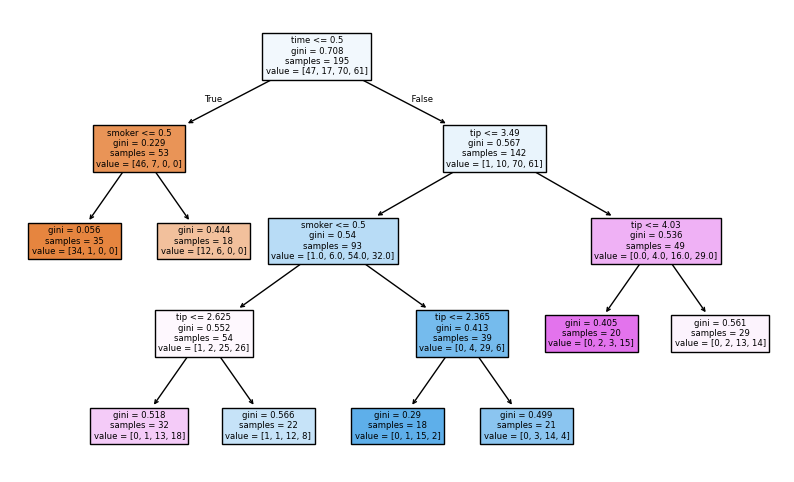

In [ ]:
plt.figure(figsize=(10,6))
plt.title("discion tree classifier visulization ")
plot_tree (
    model_new,
    feature_names=x.columns,
    filled = True
)
plt.show()

In [ ]:
data.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,3,1,2
1,10.34,1.66,1,0,3,1,3
2,21.01,3.50,1,0,3,1,3
3,23.68,3.31,1,0,3,1,2
4,24.59,3.61,0,0,3,1,4


In [ ]:
#for Regression

In [ ]:
x.head(2)


,total_bill,tip,sex,smoker,time,size
0,16.99,1.01,0,0,1,2
1,10.34,1.66,1,0,1,3


In [ ]:
y.head(2)

,day
0,3
1,3


In [ ]:
#import model
from sklearn.tree import DecisionTreeRegressor

In [ ]:
#build model
dtr = DecisionTreeRegressor()
dtr

DecisionTreeRegressor()

In [ ]:
#tain model or fit model
dtr.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
#predict the output
y_pred_rtrain = dtr.predict(x_train)
y_pred_rtest = dtr.predict(x_test)


In [ ]:
#check accuracy
acs_rtrain = accuracy_score(y_train,y_pred_rtrain)
acs_rtrain

1.0

In [ ]:
acs_rtest = accuracy_score(y_test,y_pred_rtest)
acs_rtest

0.5918367346938775